<a href="https://colab.research.google.com/github/kayorde25/satellite-embedding-benchmark/blob/main/ResNet50%20vs%20EfficientNet-B0_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Satellite Image Embedding Benchmark: ResNet50 vs EfficientNet-B0

## Overview
This notebook compares two pretrained image encoders on a satellite-imagery clustering workflow:

- **ResNet50**
- **EfficientNet-B0**

Both models are evaluated using the same pipeline:
1. Load EuroSAT satellite images
2. Extract image embeddings
3. Standardize embeddings
4. Reduce dimensions with PCA
5. Cluster with **KMeans** and **HDBSCAN**
6. Evaluate with **ARI**, **NMI**, and **silhouette score**
7. Visualize with **UMAP**


In [6]:
# Install required packages.
# hdbscan is used so we can compare centroid-based clustering (KMeans)
# with density-based clustering (HDBSCAN).

!pip install -q torch torchvision scikit-learn umap-learn matplotlib pandas numpy hdbscan

## Step 1: Import Libraries

Use:
- **PyTorch / torchvision** for dataset loading and pretrained models
- **scikit-learn** for scaling, PCA, KMeans, and evaluation metrics
- **hdbscan** for density-based clustering
- **UMAP** for 2D visualization
- **matplotlib** and **pandas** for outputs

In [7]:
# Import standard libraries
import os
import warnings

# Import PyTorch
import torch
import torch.nn as nn

# Import array and dataframe libraries
import numpy as np
import pandas as pd

# Import plotting library
import matplotlib.pyplot as plt

# Import dataset, transforms, and pretrained models from torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Import preprocessing, dimensionality reduction, clustering, and evaluation tools
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

# Import UMAP for 2D projection
import umap

# Import HDBSCAN
import hdbscan

# Hide warning messages to keep output cleaner
warnings.filterwarnings("ignore")

## Step 2: Create Output Folders

Create folders for:
- saved figures
- saved benchmark tables

In [8]:
import os
import warnings

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

import umap
import hdbscan

warnings.filterwarnings("ignore")


## Step 2: Create output folders


In [9]:
os.makedirs("/content/outputs/figures", exist_ok=True)
os.makedirs("/content/outputs/tables", exist_ok=True)

print("Output folders created:")
print("/content/outputs/figures")
print("/content/outputs/tables")


Output folders created:
/content/outputs/figures
/content/outputs/tables


## Step 3: Check device

A GPU speeds up embedding extraction.


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


## Step 4: Define image transforms

We resize to 224×224 because pretrained ResNet50 expects this input size.
We also convert images to tensors so PyTorch can process them.


In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


## Step 5: Load EuroSAT Dataset

EuroSAT is a satellite-image dataset derived from Sentinel-2 imagery.

It contains labeled land-use classes such as:
- forest
- residential
- river
- highway
- crop fields

We use it because it lets us benchmark clustering quality against known labels.

In [12]:
# Download and load EuroSAT dataset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.EuroSAT(
    root="/content/data",
    download=True,
    transform=transform
)

# Create DataLoader to load images in batches
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)

100%|██████████| 94.3M/94.3M [00:00<00:00, 179MB/s]


Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [13]:
dataset = datasets.EuroSAT(
    root="/content/data",
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)


Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Step 6: Visualize Sample Images

Before building the pipeline, we inspect a few images to confirm the dataset loaded correctly.

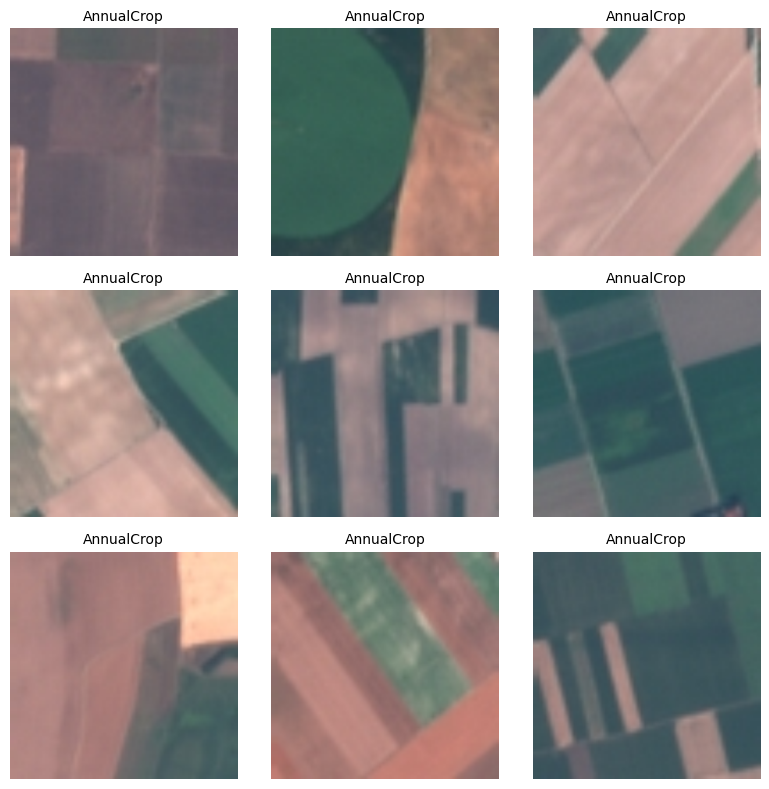

In [14]:
# Plot 9 sample images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.ravel()

for i in range(9):
    # Get one image and its label
    img, label = dataset[i]

    # Convert tensor from [C, H, W] to [H, W, C] for plotting
    img = img.permute(1, 2, 0).numpy()

    # Display image
    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label], fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Step 7: Define Model Builder

We create a helper function that:
- loads a pretrained model
- removes its final classifier layer
- returns the model as an **embedding extractor**

We remove the classifier because we want **feature embeddings**, not ImageNet class predictions.

In [15]:
def build_model(model_name):
    """
    Load a pretrained model and convert it into an embedding extractor.

    Parameters
    ----------
    model_name : str
        Name of the model to build.
        Supported:
        - "ResNet50"
        - "EfficientNet-B0"

    Returns
    -------
    model : torch.nn.Module
        Pretrained model with classification head removed.
    """

    # Build ResNet50
    if model_name == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Replace the final fully connected classifier with Identity
        # so the model outputs the 2048-dimensional embedding
        model.fc = nn.Identity()

    # Build EfficientNet-B0
    elif model_name == "EfficientNet-B0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        # Replace the final classifier with Identity
        # so the model outputs the embedding instead of class scores
        model.classifier = nn.Identity()

    # Raise an error if model name is unsupported
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    # Move model to GPU/CPU
    model = model.to(device)

    # Set to evaluation mode
    model.eval()

    return model

## Step 8: Define Embedding Extraction Function

This function runs the model over the full dataset and returns:
- the embedding matrix `X`
- the true labels `y`

In [16]:
def extract_embeddings(model, loader, device):
    """
    Extract embeddings for all images in the dataset.

    Parameters
    ----------
    model : torch.nn.Module
        Embedding model
    loader : DataLoader
        DataLoader for the dataset
    device : str
        "cuda" or "cpu"

    Returns
    -------
    X : np.ndarray
        Embedding matrix of shape [num_images, embedding_dim]
    y : np.ndarray
        Label vector of shape [num_images]
    """

    # Store all embedding batches here
    all_embeddings = []

    # Store all labels here
    all_labels = []

    # Disable gradients for faster inference
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            # Move images to device
            images = images.to(device)

            # Extract features
            feats = model(images)

            # Move features back to CPU and convert to NumPy
            all_embeddings.append(feats.cpu().numpy())

            # Save labels
            all_labels.append(labels.numpy())

            # Print progress every 100 batches
            if batch_idx % 100 == 0:
                print(f"Processed batch {batch_idx}/{len(loader)}")

    # Combine all embedding batches into one matrix
    X = np.vstack(all_embeddings)

    # Combine all label batches into one vector
    y = np.hstack(all_labels)

    return X, y

## Step 9: Define Benchmark Function

This function runs the full pipeline for one model:

1. Build model
2. Extract embeddings
3. Standardize embeddings
4. Reduce dimensions with PCA
5. Visualize with UMAP
6. Cluster with KMeans
7. Cluster with HDBSCAN
8. Evaluate both methods
9. Save figures and assignment tables

In [17]:
def run_benchmark(model_name, dataset, loader, device):
    """
    Run the full benchmark workflow for one model.

    Parameters
    ----------
    model_name : str
        Model to benchmark
    dataset : torchvision dataset
        EuroSAT dataset
    loader : DataLoader
        DataLoader for dataset
    device : str
        "cuda" or "cpu"

    Returns
    -------
    rows : list of dict
        Summary metrics for this model under KMeans and HDBSCAN
    """

    print("=" * 80)
    print(f"Running benchmark for: {model_name}")
    print("=" * 80)

    # ----------------------------
    # 1. Build embedding model
    # ----------------------------
    model = build_model(model_name)

    # ----------------------------
    # 2. Extract embeddings
    # ----------------------------
    X, y = extract_embeddings(model, loader, device)
    print(f"{model_name} embedding shape: {X.shape}")

    # ----------------------------
    # 3. Standardize embeddings
    # ----------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ----------------------------
    # 4. Reduce dimensions with PCA
    # ----------------------------
    pca = PCA(n_components=50, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    explained_variance = pca.explained_variance_ratio_.sum()
    print(f"{model_name} PCA explained variance: {explained_variance:.4f}")

    # ----------------------------
    # 5. Reduce to 2D with UMAP for plotting
    # ----------------------------
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X_pca)

    # ============================
    # KMEANS CLUSTERING
    # ============================

    # Create KMeans model
    kmeans = KMeans(
        n_clusters=10,     # EuroSAT has 10 known classes
        random_state=42,
        n_init=10
    )

    # Predict cluster labels
    clusters_kmeans = kmeans.fit_predict(X_pca)

    # Evaluate KMeans
    ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
    nmi_kmeans = normalized_mutual_info_score(y, clusters_kmeans)
    sil_kmeans = silhouette_score(X_pca, clusters_kmeans)

    # Save KMeans UMAP plot
    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_kmeans, s=5)
    plt.title(f"{model_name} - KMeans Clusters")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()

    kmeans_plot_path = f"/content/outputs/figures/{model_name.lower().replace('-', '').replace(' ', '_')}_kmeans_umap.png"
    plt.savefig(kmeans_plot_path, dpi=300, bbox_inches="tight")
    plt.close()

    # ============================
    # HDBSCAN CLUSTERING
    # ============================

    # Create HDBSCAN model
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=50,
        min_samples=10
    )

    # Predict HDBSCAN cluster labels
    clusters_hdb = hdb.fit_predict(X_pca)

    # Evaluate HDBSCAN
    ari_hdb = adjusted_rand_score(y, clusters_hdb)
    nmi_hdb = normalized_mutual_info_score(y, clusters_hdb)

    # Exclude noise points (-1) from silhouette if needed
    mask = clusters_hdb != -1
    if mask.sum() > 1 and len(np.unique(clusters_hdb[mask])) > 1:
        sil_hdb = silhouette_score(X_pca[mask], clusters_hdb[mask])
    else:
        sil_hdb = np.nan

    # Save HDBSCAN UMAP plot
    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_hdb, s=5)
    plt.title(f"{model_name} - HDBSCAN Clusters")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()

    hdb_plot_path = f"/content/outputs/figures/{model_name.lower().replace('-', '').replace(' ', '_')}_hdbscan_umap.png"
    plt.savefig(hdb_plot_path, dpi=300, bbox_inches="tight")
    plt.close()

    # Save true-label UMAP plot
    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=5)
    plt.title(f"{model_name} - True Labels")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()

    label_plot_path = f"/content/outputs/figures/{model_name.lower().replace('-', '').replace(' ', '_')}_true_labels_umap.png"
    plt.savefig(label_plot_path, dpi=300, bbox_inches="tight")
    plt.close()

    # ----------------------------
    # Build summary rows
    # ----------------------------
    rows = [
        {
            "model": model_name,
            "embedding_dim": X.shape[1],
            "clustering": "KMeans",
            "ARI": ari_kmeans,
            "NMI": nmi_kmeans,
            "Silhouette": sil_kmeans,
            "NoisePoints": 0,
            "PCA_ExplainedVariance": explained_variance,
        },
        {
            "model": model_name,
            "embedding_dim": X.shape[1],
            "clustering": "HDBSCAN",
            "ARI": ari_hdb,
            "NMI": nmi_hdb,
            "Silhouette": sil_hdb,
            "NoisePoints": int(np.sum(clusters_hdb == -1)),
            "PCA_ExplainedVariance": explained_variance,
        },
    ]

    # ----------------------------
    # Save assignment table
    # ----------------------------
    assignment_df = pd.DataFrame({
        "true_label": y,
        "true_class_name": [dataset.classes[label] for label in y],
        "umap_x": X_2d[:, 0],
        "umap_y": X_2d[:, 1],
        "kmeans_cluster": clusters_kmeans,
        "hdbscan_cluster": clusters_hdb,
    })

    assignment_path = f"/content/outputs/tables/{model_name.lower().replace('-', '').replace(' ', '_')}_cluster_assignments.csv"
    assignment_df.to_csv(assignment_path, index=False)

    return rows

## Step 10: Run Benchmark for ResNet50

ResNet50 is the first benchmark model.  
It is widely used and produces a **2048-dimensional embedding**.

In [ ]:
# Run benchmark for ResNet50
resnet_rows = run_benchmark(
    model_name="ResNet50",
    dataset=dataset,
    loader=loader,
    device=device
)

Running benchmark for: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


Processed batch 0/844


## Step 11: Run Benchmark for EfficientNet-B0

EfficientNet-B0 is often more parameter-efficient than older CNNs and produces a **1280-dimensional embedding**.

Comparing it with ResNet50 gives us a stronger benchmarking story.

In [ ]:
# Run benchmark for EfficientNet-B0
efficientnet_rows = run_benchmark(
    model_name="EfficientNet-B0",
    dataset=dataset,
    loader=loader,
    device=device
)

## Step 12: Build Comparison Table

This is the key benchmark output:
- two models
- two clustering methods
- one shared evaluation table

In [ ]:
# Combine benchmark results into one dataframe
results_df = pd.DataFrame(resnet_rows + efficientnet_rows)

# Sort for cleaner display
results_df = results_df.sort_values(["model", "clustering"]).reset_index(drop=True)

# Show results
results_df

## Step 13: Save Benchmark Results

This CSV can be committed directly to the repo under `outputs/tables/`.

In [ ]:
# Save results table
results_path = "/content/outputs/tables/model_comparison_benchmark_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)

## Step 14: Highlight Best-Performing Combinations

This step makes interpretation easier by showing which model + clustering combination performs best on selected metrics.

In [ ]:
# Find best ARI row
best_ari_row = results_df.loc[results_df["ARI"].idxmax()]

# Find best NMI row
best_nmi_row = results_df.loc[results_df["NMI"].idxmax()]

print("Best ARI combination:")
print(best_ari_row)
print()
print("Best NMI combination:")
print(best_nmi_row)

## Step 15: Why This Comparison Matters

### What this comparison tells us
- whether one encoder creates better-separated satellite-image embeddings
- whether KMeans or HDBSCAN works better with a given encoder
- whether a smaller embedding space can still perform strongly
- which encoder is the better baseline for future upgrades

## Why HDBSCAN is Often Superior to KMeans

KMeans is useful as a baseline, but HDBSCAN is often better for real embedding spaces because:

- it does **not require predefining the number of clusters**
- it handles **irregular cluster shapes**
- it works better when clusters have **different densities**
- it can mark uncertain samples as **noise** instead of forcing them into clusters

This matters in satellite imagery because some tiles are:
- mixed land-use
- ambiguous
- transitional
- visually noisy

In [ ]:
# Optional download block for Google Colab

from google.colab import files
files.download("/content/outputs/tables/model_comparison_benchmark_results.csv")
files.download("/content/outputs/figures/resnet50_kmeans_umap.png")
files.download("/content/outputs/figures/resnet50_hdbscan_umap.png")
files.download("/content/outputs/figures/efficientnetb0_kmeans_umap.png")
files.download("/content/outputs/figures/efficientnetb0_hdbscan_umap.png")

# Conclusion

## What this notebook adds
This notebook upgrades the project by comparing:

- **ResNet50 vs EfficientNet-B0**
- **KMeans vs HDBSCAN**

under the same dataset and evaluation pipeline.

## Why this improves the project
It shows:
- model comparison
- benchmarking discipline
- reproducibility
- evidence-based method selection

## Best next upgrade
A strong next step would be:
- adding **ViT or CLIP**
- testing **embedding fusion**
- adding **qualitative cluster comparison panels**
- moving to real **GeoTIFF satellite imagery**